In [1]:
# AI Smart Traffic Intelligence System

In [2]:
import sys
print(sys.executable)

C:\Users\sanjay choudhary\anaconda3\python.exe


In [3]:
#import sys

#!"{sys.executable}" -m pip install ultralytics

In [4]:
# Section 1: Import Required Libraries
import cv2
from ultralytics import YOLO 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import time
from datetime import datetime
import os
# Basic Environment Check
print("All required libraries imported successfully.")

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

All required libraries imported successfully.
OpenCV version: 4.13.0
NumPy version: 2.3.5
Pandas version: 2.3.3


In [5]:
# Section 2: Initialize YOLO Model
MODEL_NAME = "yolo26n.pt"

CONFIDENCE_THRESHOLD = 0.40

IMAGE_SIZE = 640
DEVICE = "cpu"
# Load the YOLO model
model = YOLO(MODEL_NAME)

print("YOLO model loaded successfully.")
print("Model name:", MODEL_NAME)
print("Device:", DEVICE)
print("Confidence threshold:", CONFIDENCE_THRESHOLD)
print("Image size:", IMAGE_SIZE)

YOLO model loaded successfully.
Model name: yolo26n.pt
Device: cpu
Confidence threshold: 0.4
Image size: 640


Video source opened successfully.
First frame captured successfully.
Frame shape: (480, 640, 3)


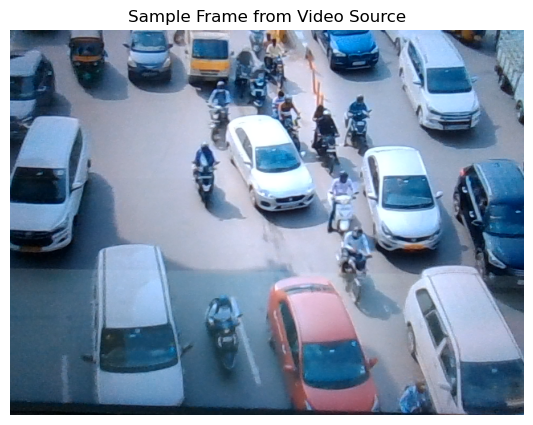

In [6]:
# Section 3: Capture Video from Webcam or Video File
INPUT_SOURCE = "webcam"

VIDEO_PATH = "traffic_video.mp4"

WEBCAM_INDEX = 0


def get_video_capture(input_source, video_path=None, webcam_index=0):
    """
    Create and return an OpenCV video capture object.

    Parameters:
    input_source:
        "webcam" for laptop webcam
        "video" for saved video file

    video_path:
        Path of the video file if input_source is "video"

    webcam_index:
        Camera index for webcam input

    Returns:
    cap:
        OpenCV VideoCapture object
    """

    if input_source == "webcam":
        cap = cv2.VideoCapture(webcam_index)

    elif input_source == "video":
        cap = cv2.VideoCapture(video_path)

    else:
        raise ValueError("INPUT_SOURCE must be either 'webcam' or 'video'.")

    return cap

# Create video capture object
cap = get_video_capture(
    input_source=INPUT_SOURCE,
    video_path=VIDEO_PATH,
    webcam_index=WEBCAM_INDEX
)

# Check if video source opened correctly
if not cap.isOpened():
    print("Error: Could not open video source.")
    print("Please check webcam connection or video file path.")
else:
    print("Video source opened successfully.")

    # Read one frame to test the video source
    success, frame = cap.read()

    if success:
        print("First frame captured successfully.")
        print("Frame shape:", frame.shape)

        # Convert BGR frame to RGB for Matplotlib display
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(8, 5))
        plt.imshow(frame_rgb)
        plt.title("Sample Frame from Video Source")
        plt.axis("off")
        plt.show()

    else:
        print("Error: Could not read frame from video source.")

# Release video source after testing
cap.release()

In [7]:
# Section 4: Run Object Detection for Vehicles Only
VEHICLE_CLASS_IDS = [2, 3, 5, 7]

VEHICLE_CLASS_NAMES = {
    2: "car",
    3: "motorcycle",
    5: "bus",
    7: "truck"
}


def detect_vehicles(frame, model):
    """
    Run YOLO object detection on one video frame.

    Parameters:
    frame:
        One image/frame captured using OpenCV.
        OpenCV reads images in BGR format.

    model:
        Loaded YOLO model from Ultralytics.

    Returns:
    detections:
        A list of dictionaries.
        Each dictionary contains vehicle name, confidence, and bounding box.
    """

    # Run YOLO prediction on the frame
    results = model.predict(
        source=frame,
        conf=CONFIDENCE_THRESHOLD,
        imgsz=IMAGE_SIZE,
        device=DEVICE,
        classes=VEHICLE_CLASS_IDS,
        verbose=False
    )

    detections = []

    # results[0] contains detections for the current frame
    result = results[0]

    # result.boxes contains all detected bounding boxes
    for box in result.boxes:
        # xyxy format means:
        # x1, y1 = top-left corner
        # x2, y2 = bottom-right corner
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)

        # Confidence score of detection
        confidence = float(box.conf[0].cpu().numpy())

        # Class ID predicted by YOLO
        class_id = int(box.cls[0].cpu().numpy())

        # Convert class ID to vehicle name
        vehicle_name = VEHICLE_CLASS_NAMES[class_id]

        detection = {
            "vehicle_name": vehicle_name,
            "confidence": confidence,
            "bbox": (x1, y1, x2, y2)
        }

        detections.append(detection)

    return detections
# Test detection on one frame
# Open video source again for testing detection
cap = get_video_capture(
    input_source=INPUT_SOURCE,
    video_path=VIDEO_PATH,
    webcam_index=WEBCAM_INDEX
)

if not cap.isOpened():
    print("Error: Could not open video source.")
else:
    success, frame = cap.read()

    if success:
        detections = detect_vehicles(frame, model)

        print("Detection completed successfully.")
        print("Number of vehicles detected:", len(detections))

        for detection in detections:
            print(detection)

    else:
        print("Error: Could not read frame from video source.")

cap.release()

Detection completed successfully.
Number of vehicles detected: 12
{'vehicle_name': 'car', 'confidence': 0.8945533633232117, 'bbox': (np.int64(458), np.int64(161), np.int64(581), np.int64(327))}
{'vehicle_name': 'car', 'confidence': 0.8712419867515564, 'bbox': (np.int64(0), np.int64(162), np.int64(91), np.int64(391))}
{'vehicle_name': 'car', 'confidence': 0.8647861480712891, 'bbox': (np.int64(154), np.int64(0), np.int64(227), np.int64(89))}
{'vehicle_name': 'car', 'confidence': 0.860988199710846, 'bbox': (np.int64(343), np.int64(310), np.int64(491), np.int64(471))}
{'vehicle_name': 'car', 'confidence': 0.8521447777748108, 'bbox': (np.int64(409), np.int64(0), np.int64(483), np.int64(47))}
{'vehicle_name': 'car', 'confidence': 0.7870403528213501, 'bbox': (np.int64(504), np.int64(0), np.int64(613), np.int64(110))}
{'vehicle_name': 'car', 'confidence': 0.7119826078414917, 'bbox': (np.int64(289), np.int64(78), np.int64(410), np.int64(210))}
{'vehicle_name': 'car', 'confidence': 0.62087750434

Bounding boxes drawn successfully.
Vehicles detected: 13


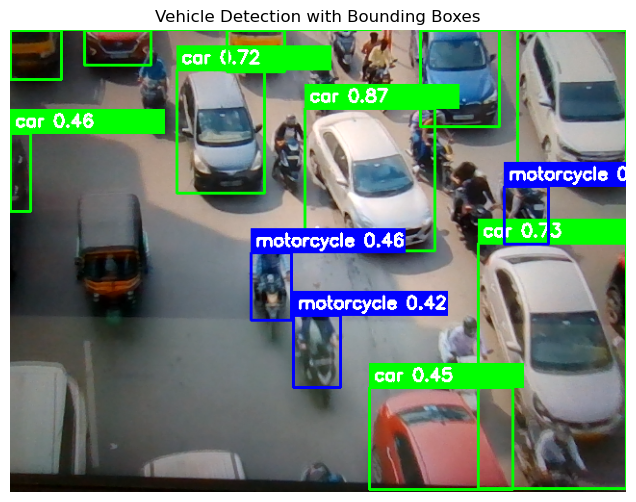

In [8]:
# Section 5: Draw Bounding Boxes on Detected Vehicles
# Unique colors for each vehicle type in BGR format
VEHICLE_COLORS = {
    "car": (0, 255, 0),          # Green
    "motorcycle": (255, 0, 0),   # Blue
    "bus": (0, 165, 255),        # Orange
    "truck": (0, 0, 255)         # Red
}


def draw_vehicle_boxes(frame, detections):
    """
    Draw bounding boxes, vehicle names, and confidence scores on a frame.

    Parameters:
    frame:
        Original video frame from OpenCV.

    detections:
        List of detection dictionaries returned by detect_vehicles().

    Returns:
    output_frame:
        Frame with bounding boxes and labels drawn.
    """

    # Create a copy so original frame is not modified directly
    output_frame = frame.copy()

    for detection in detections:
        vehicle_name = detection["vehicle_name"]
        confidence = detection["confidence"]
        x1, y1, x2, y2 = detection["bbox"]

        # Get color based on vehicle type
        color = VEHICLE_COLORS.get(vehicle_name, (255, 255, 255))

        # Prepare label text
        label = f"{vehicle_name} {confidence:.2f}"

        # Draw bounding box
        cv2.rectangle(
            output_frame,
            (x1, y1),
            (x2, y2),
            color,
            thickness=2
        )

        # Draw filled rectangle behind text for better readability
        cv2.rectangle(
            output_frame,
            (x1, y1 - 25),
            (x1 + 160, y1),
            color,
            thickness=-1
        )

        # Draw label text
        cv2.putText(
            output_frame,
            label,
            (x1 + 5, y1 - 7),
            cv2.FONT_HERSHEY_SIMPLEX,
            fontScale=0.6,
            color=(255, 255, 255),
            thickness=2
        )

    return output_frame
# Test bounding boxes on one frame
cap = get_video_capture(
    input_source=INPUT_SOURCE,
    video_path=VIDEO_PATH,
    webcam_index=WEBCAM_INDEX
)

if not cap.isOpened():
    print("Error: Could not open video source.")
else:
    success, frame = cap.read()

    if success:
        detections = detect_vehicles(frame, model)
        output_frame = draw_vehicle_boxes(frame, detections)

        print("Bounding boxes drawn successfully.")
        print("Vehicles detected:", len(detections))

        # Convert BGR to RGB before displaying with Matplotlib
        output_frame_rgb = cv2.cvtColor(output_frame, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 6))
        plt.imshow(output_frame_rgb)
        plt.title("Vehicle Detection with Bounding Boxes")
        plt.axis("off")
        plt.show()

    else:
        print("Error: Could not read frame from video source.")

cap.release()

In [9]:
# Section 6: Count Vehicles
def count_vehicles(detections):
    """
    Count vehicles from YOLO detection results.

    Parameters:
    detections:
        List of detection dictionaries returned by detect_vehicles().

    Returns:
    vehicle_counts:
        Dictionary containing count of each vehicle type and total vehicles.
    """

    # Extract vehicle names from detections
    vehicle_names = []

    for detection in detections:
        vehicle_names.append(detection["vehicle_name"])

    # Count each vehicle type
    counted_vehicles = Counter(vehicle_names)

    # Create clean dictionary with all expected vehicle types
    vehicle_counts = {
        "cars": counted_vehicles.get("car", 0),
        "motorcycles": counted_vehicles.get("motorcycle", 0),
        "buses": counted_vehicles.get("bus", 0),
        "trucks": counted_vehicles.get("truck", 0)
    }

    # Calculate total vehicles
    vehicle_counts["total"] = (
        vehicle_counts["cars"]
        + vehicle_counts["motorcycles"]
        + vehicle_counts["buses"]
        + vehicle_counts["trucks"]
    )

    return vehicle_counts

# Test vehicle counting on one frame
cap = get_video_capture(
    input_source=INPUT_SOURCE,
    video_path=VIDEO_PATH,
    webcam_index=WEBCAM_INDEX
)

if not cap.isOpened():
    print("Error: Could not open video source.")
else:
    success, frame = cap.read()

    if success:
        detections = detect_vehicles(frame, model)
        vehicle_counts = count_vehicles(detections)

        print("Vehicle counting completed successfully.")
        print("Cars:", vehicle_counts["cars"])
        print("Motorcycles:", vehicle_counts["motorcycles"])
        print("Buses:", vehicle_counts["buses"])
        print("Trucks:", vehicle_counts["trucks"])
        print("Total Vehicles:", vehicle_counts["total"])

    else:
        print("Error: Could not read frame from video source.")

cap.release()

Vehicle counting completed successfully.
Cars: 9
Motorcycles: 3
Buses: 0
Trucks: 0
Total Vehicles: 12


In [10]:
# Section 7: Traffic Density Analysis
LOW_TRAFFIC_LIMIT = 5
MEDIUM_TRAFFIC_LIMIT = 15


def analyze_traffic_density(total_vehicles):
    """
    Analyze traffic density based on total detected vehicles.

    Parameters:
    total_vehicles:
        Total number of detected vehicles in the current frame.

    Returns:
    traffic_density:
        Traffic density category as a string.
    """

    if total_vehicles <= LOW_TRAFFIC_LIMIT:
        traffic_density = "Low Traffic"

    elif total_vehicles <= MEDIUM_TRAFFIC_LIMIT:
        traffic_density = "Medium Traffic"

    else:
        traffic_density = "High Traffic"

    return traffic_density

# Test traffic density analysis on one frame
cap = get_video_capture(
    input_source=INPUT_SOURCE,
    video_path=VIDEO_PATH,
    webcam_index=WEBCAM_INDEX
)

if not cap.isOpened():
    print("Error: Could not open video source.")
else:
    success, frame = cap.read()

    if success:
        detections = detect_vehicles(frame, model)
        vehicle_counts = count_vehicles(detections)

        traffic_density = analyze_traffic_density(
            total_vehicles=vehicle_counts["total"]
        )

        print("Traffic density analysis completed successfully.")
        print("Total Vehicles:", vehicle_counts["total"])
        print("Traffic Density:", traffic_density)

    else:
        print("Error: Could not read frame from video source.")

cap.release()

Traffic density analysis completed successfully.
Total Vehicles: 10
Traffic Density: Medium Traffic


In [11]:
# Section 8: Adaptive Signal Logic
def recommend_signal_time(traffic_density):
    """
    Recommend green signal time based on traffic density.

    Parameters:
    traffic_density:
        Traffic density category.
        Expected values:
        "Low Traffic", "Medium Traffic", "High Traffic"

    Returns:
    signal_time:
        Recommended green signal time in seconds.
    """

    if traffic_density == "Low Traffic":
        signal_time = 20

    elif traffic_density == "Medium Traffic":
        signal_time = 40

    elif traffic_density == "High Traffic":
        signal_time = 70

    else:
        signal_time = 20

    return signal_time
    
# Test adaptive signal logic on one frame
cap = get_video_capture(
    input_source=INPUT_SOURCE,
    video_path=VIDEO_PATH,
    webcam_index=WEBCAM_INDEX
)

if not cap.isOpened():
    print("Error: Could not open video source.")
else:
    success, frame = cap.read()

    if success:
        detections = detect_vehicles(frame, model)
        vehicle_counts = count_vehicles(detections)

        traffic_density = analyze_traffic_density(
            total_vehicles=vehicle_counts["total"]
        )

        signal_time = recommend_signal_time(
            traffic_density=traffic_density
        )

        print("Adaptive signal logic completed successfully.")
        print("Total Vehicles:", vehicle_counts["total"])
        print("Traffic Density:", traffic_density)
        print("Recommended Green Signal Time:", signal_time, "seconds")

    else:
        print("Error: Could not read frame from video source.")

cap.release()

Adaptive signal logic completed successfully.
Total Vehicles: 7
Traffic Density: Medium Traffic
Recommended Green Signal Time: 40 seconds


Dashboard overlay created successfully.


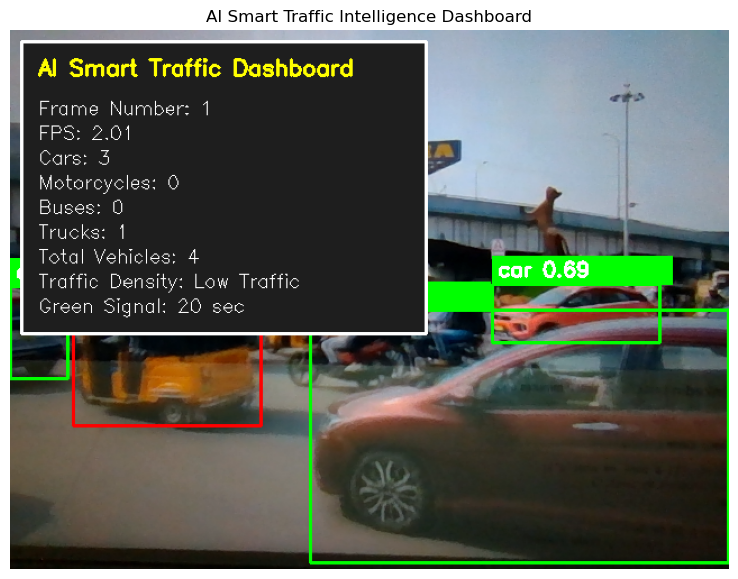

In [12]:
# Section 9: Dashboard Overlay
def calculate_fps(start_time, end_time):
    """
    Calculate frames per second based on frame processing time.

    Parameters:
    start_time:
        Time before processing starts.

    end_time:
        Time after processing ends.

    Returns:
    fps:
        Frames processed per second.
    """

    processing_time = end_time - start_time

    if processing_time == 0:
        fps = 0
    else:
        fps = 1 / processing_time

    return fps


def draw_dashboard(frame, vehicle_counts, traffic_density,
                   signal_time, fps, frame_number):
    """
    Draw dashboard information on the video frame.

    Parameters:
    frame:
        Frame on which dashboard will be drawn.

    vehicle_counts:
        Dictionary containing vehicle counts.

    traffic_density:
        Current traffic density category.

    signal_time:
        Recommended green signal time in seconds.

    fps:
        Current processing FPS.

    frame_number:
        Current video frame number.

    Returns:
    output_frame:
        Frame with dashboard overlay.
    """

    output_frame = frame.copy()

    # Dashboard background position
    x_start = 10
    y_start = 10
    box_width = 360
    box_height = 260

    # Draw dark dashboard background
    cv2.rectangle(
        output_frame,
        (x_start, y_start),
        (x_start + box_width, y_start + box_height),
        (30, 30, 30),
        thickness=-1
    )

    # Draw dashboard border
    cv2.rectangle(
        output_frame,
        (x_start, y_start),
        (x_start + box_width, y_start + box_height),
        (255, 255, 255),
        thickness=2
    )

    # Dashboard title
    cv2.putText(
        output_frame,
        "AI Smart Traffic Dashboard",
        (x_start + 15, y_start + 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        (0, 255, 255),
        2
    )

    # Dashboard text lines
    dashboard_lines = [
        f"Frame Number: {frame_number}",
        f"FPS: {fps:.2f}",
        f"Cars: {vehicle_counts['cars']}",
        f"Motorcycles: {vehicle_counts['motorcycles']}",
        f"Buses: {vehicle_counts['buses']}",
        f"Trucks: {vehicle_counts['trucks']}",
        f"Total Vehicles: {vehicle_counts['total']}",
        f"Traffic Density: {traffic_density}",
        f"Green Signal: {signal_time} sec"
    ]

    y_position = y_start + 65

    for line in dashboard_lines:
        cv2.putText(
            output_frame,
            line,
            (x_start + 15, y_position),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (255, 255, 255),
            1
        )

        y_position += 22

    return output_frame

# Test dashboard overlay on one frame
cap = get_video_capture(
    input_source=INPUT_SOURCE,
    video_path=VIDEO_PATH,
    webcam_index=WEBCAM_INDEX
)

if not cap.isOpened():
    print("Error: Could not open video source.")
else:
    frame_number = 1

    start_time = time.time()
    success, frame = cap.read()

    if success:
        detections = detect_vehicles(frame, model)
        vehicle_counts = count_vehicles(detections)

        traffic_density = analyze_traffic_density(
            total_vehicles=vehicle_counts["total"]
        )

        signal_time = recommend_signal_time(
            traffic_density=traffic_density
        )

        frame_with_boxes = draw_vehicle_boxes(frame, detections)

        end_time = time.time()
        fps = calculate_fps(start_time, end_time)

        dashboard_frame = draw_dashboard(
            frame=frame_with_boxes,
            vehicle_counts=vehicle_counts,
            traffic_density=traffic_density,
            signal_time=signal_time,
            fps=fps,
            frame_number=frame_number
        )

        print("Dashboard overlay created successfully.")

        # Convert BGR to RGB for Matplotlib display
        dashboard_frame_rgb = cv2.cvtColor(
            dashboard_frame,
            cv2.COLOR_BGR2RGB
        )

        plt.figure(figsize=(12, 7))
        plt.imshow(dashboard_frame_rgb)
        plt.title("AI Smart Traffic Intelligence Dashboard")
        plt.axis("off")
        plt.show()

    else:
        print("Error: Could not read frame from video source.")

cap.release()

In [13]:
# Section 10: Data Logging and CSV Export
MAX_FRAMES = 100
CSV_FILE_NAME = "traffic_data_log.csv"

def create_frame_log(vehicle_counts, traffic_density, signal_time):
    """
    Create one log record for the current video frame.

    Parameters:
    vehicle_counts:
        Dictionary containing vehicle counts.

    traffic_density:
        Traffic density category.

    signal_time:
        Recommended green signal time.

    Returns:
    frame_log:
        Dictionary containing traffic data for one frame.
    """

    frame_log = {
        "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Cars": vehicle_counts["cars"],
        "Motorcycles": vehicle_counts["motorcycles"],
        "Buses": vehicle_counts["buses"],
        "Trucks": vehicle_counts["trucks"],
        "Total Vehicles": vehicle_counts["total"],
        "Traffic Density": traffic_density,
        "Signal Time": signal_time
    }

    return frame_log


def process_video_for_logging(input_source, video_path, webcam_index,
                              max_frames=None):
    """
    Process video/webcam frames and store traffic data.

    Parameters:
    input_source:
        "webcam" or "video"

    video_path:
        Path of video file if input source is video.

    webcam_index:
        Webcam index if input source is webcam.

    max_frames:
        Maximum number of frames to process.
        Use None to process full video file.

    Returns:
    traffic_df:
        Pandas DataFrame containing logged traffic data.
    """

    cap = get_video_capture(
        input_source=input_source,
        video_path=video_path,
        webcam_index=webcam_index
    )

    if not cap.isOpened():
        print("Error: Could not open video source.")
        return pd.DataFrame()

    traffic_logs = []
    frame_number = 0

    print("Processing started...")

    while True:
        success, frame = cap.read()

        if not success:
            print("No more frames available.")
            break

        frame_number += 1

        detections = detect_vehicles(frame, model)
        vehicle_counts = count_vehicles(detections)

        traffic_density = analyze_traffic_density(
            total_vehicles=vehicle_counts["total"]
        )

        signal_time = recommend_signal_time(
            traffic_density=traffic_density
        )

        frame_log = create_frame_log(
            vehicle_counts=vehicle_counts,
            traffic_density=traffic_density,
            signal_time=signal_time
        )

        traffic_logs.append(frame_log)

        if frame_number % 10 == 0:
            print("Processed frames:", frame_number)

        if max_frames is not None and frame_number >= max_frames:
            print("Reached maximum frame limit.")
            break

    cap.release()

    traffic_df = pd.DataFrame(traffic_logs)

    return traffic_df

# Run data logging
traffic_df = process_video_for_logging(
    input_source=INPUT_SOURCE,
    video_path=VIDEO_PATH,
    webcam_index=WEBCAM_INDEX,
    max_frames=MAX_FRAMES
)

if not traffic_df.empty:
    traffic_df.to_csv(CSV_FILE_NAME, index=False)

    print("Data logging completed successfully.")
    print("CSV file saved as:", CSV_FILE_NAME)
    print("Total logged frames:", len(traffic_df))

    display(traffic_df.head())
else:
    print("No data was logged.")

Processing started...
Processed frames: 10
Processed frames: 20
Processed frames: 30
Processed frames: 40
Processed frames: 50
Processed frames: 60
Processed frames: 70
Processed frames: 80
Processed frames: 90
Processed frames: 100
Reached maximum frame limit.
Data logging completed successfully.
CSV file saved as: traffic_data_log.csv
Total logged frames: 100


,Timestamp,Cars,Motorcycles,Buses,Trucks,Total Vehicles,Traffic Density,Signal Time
0,2026-07-06 09:02:35,3,0,0,1,4,Low Traffic,20
1,2026-07-06 09:02:35,3,0,0,1,4,Low Traffic,20
2,2026-07-06 09:02:35,2,0,0,1,3,Low Traffic,20
3,2026-07-06 09:02:36,4,0,0,0,4,Low Traffic,20
4,2026-07-06 09:02:36,4,1,0,1,6,Medium Traffic,40


Generating graphs...


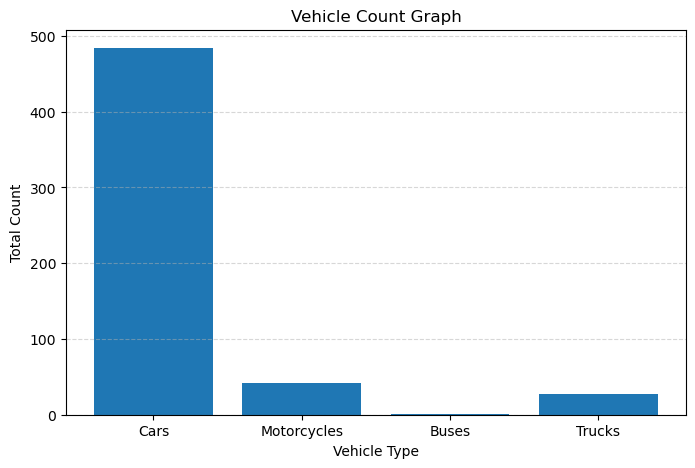

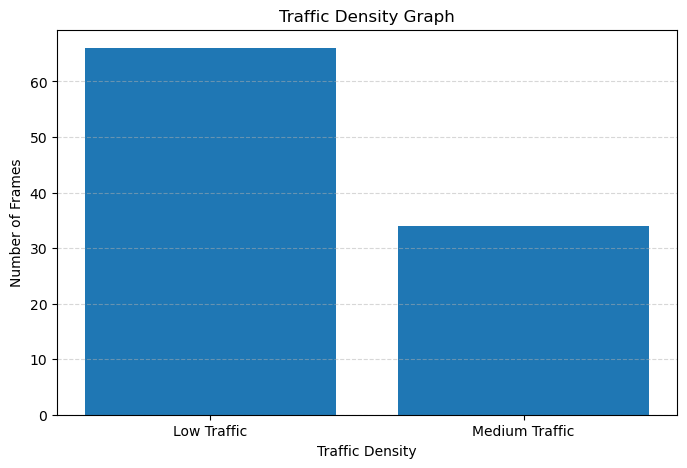

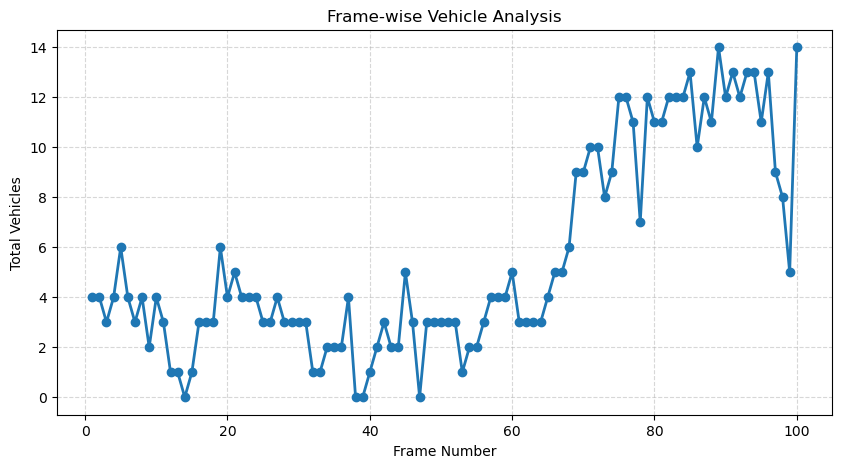

Graphs generated successfully.


In [14]:
# Section 11: Generate Graphs Using Matplotlib
def plot_vehicle_count_graph(traffic_df):
    """
    Plot total count of each vehicle type.

    Parameters:
    traffic_df:
        Pandas DataFrame containing traffic log data.
    """

    vehicle_totals = {
        "Cars": traffic_df["Cars"].sum(),
        "Motorcycles": traffic_df["Motorcycles"].sum(),
        "Buses": traffic_df["Buses"].sum(),
        "Trucks": traffic_df["Trucks"].sum()
    }

    vehicle_names = list(vehicle_totals.keys())
    vehicle_counts = list(vehicle_totals.values())

    plt.figure(figsize=(8, 5))
    plt.bar(vehicle_names, vehicle_counts)
    plt.title("Vehicle Count Graph")
    plt.xlabel("Vehicle Type")
    plt.ylabel("Total Count")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()


def plot_traffic_density_graph(traffic_df):
    """
    Plot number of frames for each traffic density category.

    Parameters:
    traffic_df:
        Pandas DataFrame containing traffic log data.
    """

    density_counts = traffic_df["Traffic Density"].value_counts()

    plt.figure(figsize=(8, 5))
    plt.bar(density_counts.index, density_counts.values)
    plt.title("Traffic Density Graph")
    plt.xlabel("Traffic Density")
    plt.ylabel("Number of Frames")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()


def plot_frame_wise_analysis(traffic_df):
    """
    Plot total vehicles detected per frame.

    Parameters:
    traffic_df:
        Pandas DataFrame containing traffic log data.
    """

    frame_numbers = range(1, len(traffic_df) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(
        frame_numbers,
        traffic_df["Total Vehicles"],
        marker="o",
        linewidth=2
    )

    plt.title("Frame-wise Vehicle Analysis")
    plt.xlabel("Frame Number")
    plt.ylabel("Total Vehicles")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

# Generate all graphs
if "traffic_df" not in globals():
    print("traffic_df not found. Please run Section 10 first.")

elif traffic_df.empty:
    print("traffic_df is empty. Please run Section 10 with valid video input.")

else:
    print("Generating graphs...")

    plot_vehicle_count_graph(traffic_df)
    plot_traffic_density_graph(traffic_df)
    plot_frame_wise_analysis(traffic_df)

    print("Graphs generated successfully.")

In [15]:
# Section 12: Clean Reusable Final Pipeline
def run_smart_traffic_system(input_source="webcam",
                             video_path="traffic_video.mp4",
                             webcam_index=0,
                             max_frames=100,
                             save_csv=True,
                             csv_file_name="traffic_data_log.csv",
                             show_video=True):
    """
    Run the complete AI Smart Traffic Intelligence System.

    Parameters:
    input_source:
        "webcam" for laptop camera
        "video" for traffic video file

    video_path:
        Path to traffic video file when input_source is "video"

    webcam_index:
        Webcam index, usually 0 for default laptop webcam

    max_frames:
        Maximum number of frames to process.
        Use small number for average laptops.
        Use None for full video processing.

    save_csv:
        If True, save traffic logs to CSV.

    csv_file_name:
        Name of output CSV file.

    show_video:
        If True, display OpenCV video window.

    Returns:
    traffic_df:
        Pandas DataFrame containing traffic log data.
    """

    cap = get_video_capture(
        input_source=input_source,
        video_path=video_path,
        webcam_index=webcam_index
    )

    if not cap.isOpened():
        print("Error: Could not open video source.")
        return pd.DataFrame()

    traffic_logs = []
    frame_number = 0

    print("AI Smart Traffic Intelligence System started.")
    print("Press 'q' in the video window to stop.")

    while True:
        start_time = time.time()

        success, frame = cap.read()

        if not success:
            print("No more frames available.")
            break

        frame_number += 1

        # Step 1: Detect vehicles
        detections = detect_vehicles(frame, model)

        # Step 2: Count vehicles
        vehicle_counts = count_vehicles(detections)

        # Step 3: Analyze traffic density
        traffic_density = analyze_traffic_density(
            total_vehicles=vehicle_counts["total"]
        )

        # Step 4: Recommend signal time
        signal_time = recommend_signal_time(
            traffic_density=traffic_density
        )

        # Step 5: Draw bounding boxes
        frame_with_boxes = draw_vehicle_boxes(frame, detections)

        end_time = time.time()

        # Step 6: Calculate FPS
        fps = calculate_fps(start_time, end_time)

        # Step 7: Draw dashboard
        dashboard_frame = draw_dashboard(
            frame=frame_with_boxes,
            vehicle_counts=vehicle_counts,
            traffic_density=traffic_density,
            signal_time=signal_time,
            fps=fps,
            frame_number=frame_number
        )

        # Step 8: Create frame log
        frame_log = create_frame_log(
            vehicle_counts=vehicle_counts,
            traffic_density=traffic_density,
            signal_time=signal_time
        )

        traffic_logs.append(frame_log)

        # Step 9: Display video output
        if show_video:
            cv2.imshow(
                "AI Smart Traffic Intelligence System",
                dashboard_frame
            )

            # Press q to stop
            if cv2.waitKey(1) & 0xFF == ord("q"):
                print("Stopped by user.")
                break

        if frame_number % 10 == 0:
            print("Processed frames:", frame_number)

        if max_frames is not None and frame_number >= max_frames:
            print("Reached maximum frame limit.")
            break

    cap.release()
    cv2.destroyAllWindows()

    traffic_df = pd.DataFrame(traffic_logs)

    if save_csv and not traffic_df.empty:
        traffic_df.to_csv(csv_file_name, index=False)
        print("CSV file saved successfully:", csv_file_name)

    print("Processing completed.")
    print("Total frames processed:", frame_number)

    return traffic_df

# Run Final System
final_traffic_df = run_smart_traffic_system(
    input_source=INPUT_SOURCE,
    video_path=VIDEO_PATH,
    webcam_index=WEBCAM_INDEX,
    max_frames=MAX_FRAMES,
    save_csv=True,
    csv_file_name=CSV_FILE_NAME,
    show_video=True
)

display(final_traffic_df.head())

AI Smart Traffic Intelligence System started.
Press 'q' in the video window to stop.
Processed frames: 10
Processed frames: 20
Processed frames: 30
Processed frames: 40
Processed frames: 50
Processed frames: 60
Processed frames: 70
Processed frames: 80
Processed frames: 90
Processed frames: 100
Reached maximum frame limit.
CSV file saved successfully: traffic_data_log.csv
Processing completed.
Total frames processed: 100


,Timestamp,Cars,Motorcycles,Buses,Trucks,Total Vehicles,Traffic Density,Signal Time
0,2026-07-06 09:03:00,11,0,0,0,11,Medium Traffic,40
1,2026-07-06 09:03:00,13,0,0,0,13,Medium Traffic,40
2,2026-07-06 09:03:00,15,0,0,0,15,Medium Traffic,40
3,2026-07-06 09:03:00,15,0,0,0,15,Medium Traffic,40
4,2026-07-06 09:03:01,17,0,0,0,17,High Traffic,70
